In [1]:
import sys
import os
import numpy as np
import datetime

import matplotlib.pyplot as plt
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
import xmitgcm as xm

In [2]:
model = 'lucerne_test'
mitgcm_config, ds_vel = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
def repair_coord(ds, grid_resolution):
    ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
    ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
    ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
    ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

    return ds

In [4]:
dt_save = 3600
res_grid = 100

## Velocity & Temperature

In [5]:
ds_vel = repair_coord(ds_vel, res_grid)

# Heatfluxes

In [9]:
ds_hf = xm.open_mdsdataset(
    mitgcm_config['datapath'],
    grid_dir=mitgcm_config['gridpath'],
    ref_date=mitgcm_config['ref_date'],
    prefix='heatflux',
    delta_t=mitgcm_config['dt'],
    endian='>')

In [13]:
ds_hf = repair_coord(ds_hf, res_grid)

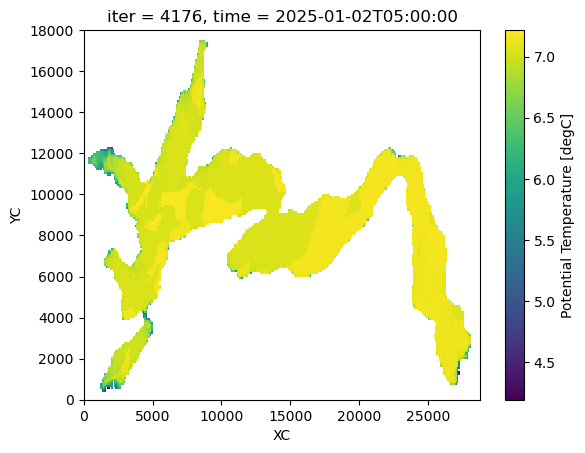

In [67]:
var = 'THETA'
ds_hf[var] = ds_hf[var].where(ds_hf['THETA'] != 0, np.nan)
ds_hf[var].isel(time=-1).plot()

## Ext forcing diagnostic

In [60]:
ds_exf = xm.open_mdsdataset(
    mitgcm_config['datapath'],
    grid_dir=mitgcm_config['gridpath'],
    ref_date=mitgcm_config['ref_date'],
    prefix='external_forcing',
    delta_t=mitgcm_config['dt'],
    endian='>')

In [61]:
ds_exf = repair_coord(ds_exf, res_grid)

In [33]:
ds_exf

<xarray.Dataset> Size: 209MB
Dimensions:   (XC: 288, YC: 180, XG: 288, YG: 180, Z: 80, Zp1: 81, Zu: 80,
               Zl: 80, time: 77)
Coordinates: (12/37)
  * XC        (XC) float64 2kB 50.0 150.0 250.0 ... 2.865e+04 2.875e+04
  * YC        (YC) float64 1kB 50.0 150.0 250.0 ... 1.785e+04 1.795e+04
  * XG        (XG) int64 2kB 0 100 200 300 400 ... 28300 28400 28500 28600 28700
  * YG        (YG) int64 1kB 0 100 200 300 400 ... 17500 17600 17700 17800 17900
  * Z         (Z) >f4 320B -0.25 -0.75 -1.25 -1.75 ... -205.0 -209.2 -212.7
  * Zp1       (Zp1) >f4 324B 0.0 -0.5 -1.0 -1.5 ... -202.8 -207.2 -211.2 -214.2
    ...        ...
    maskInW   (YC, XG) bool 52kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    dxV       (YG, XG) >f4 207kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    dxF       (YC, XC) >f4 207kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    dyF       (YC, XC) >f4 207kB dask.array<chunksize=(180, 288), meta=np.ndarray>
    iter      (time) int64 616B dask.array<chunksize=(1,), meta=np.ndarray>
  * time      (time) datetime64[ns] 616B 2025-01-01T01:00:00 ... 2025-01-04T0...
Data variables:
    EXFlwnet  (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFswnet  (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFhl     (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFhs     (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFtaux   (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFtauy   (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFuwind  (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFvwind  (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    EXFqnet   (time, YC, XC) float32 16MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/home/leroqua...

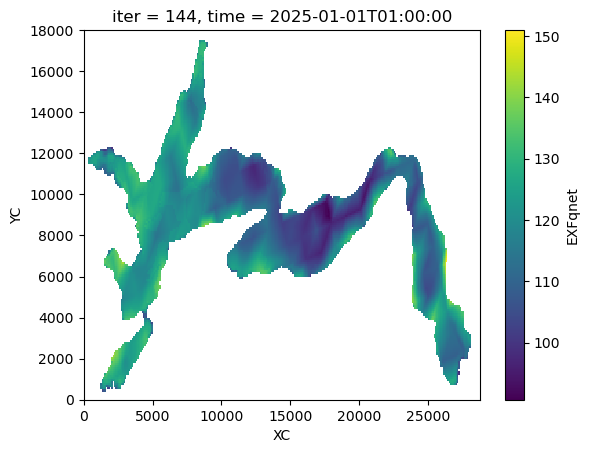

In [65]:
var = 'EXFqnet'
ds_exf[var] = ds_exf[var].where(ds_exf['EXFhl'] != 0, np.nan)
ds_exf[var].mean(dim='time').where(ds_exf.isel(time=0)['EXFhl'] != 0, np.nan).plot()